In [1]:
import yaml

from api_call import fetch_data_pacific, fetch_structure_pacific

import pycountry

# Notebook 02 — Data Collection

Fetches all Pacific Data Hub datasets needed for the visualization via the SPC SDMX API.

**Sections:**
1. Population — country list and sizes
2. GHG emissions per capita — LCA numerator for pyaesa ASR computation
3. Climate change indicators — sea level, temperature, disasters (Acts 4 & 5)

In [3]:
population = fetch_data_pacific(
    source="DF_POP_DENSITY", 
    start_period="2024", 
    end_period="2024", 
    key="A..")

## 1. Population

Fetch population, land area, and density for all Pacific territories from `DF_POP_DENSITY`. Used to build the country list and to convert per capita GHG to total national emissions.

In [4]:
population.head()

,TIME_PERIOD,FREQ,GEO_PICT,INDICATOR,value
0,2024,A,_T,POPULATION,14050000.0
1,2024,A,_T,LANDAREA,540658.0
2,2024,A,_T,POPDENSITY,26.0
3,2024,A,MEL,POPULATION,12830000.0
4,2024,A,MEL,LANDAREA,529590.0


In [5]:
# print unique values in GEO_PICT column and INDICATOR column, as lists
print("Unique values in GEO_PICT column:", population['GEO_PICT'].unique().tolist())
print("Unique values in INDICATOR column:", population['INDICATOR'].unique().tolist())

Unique values in GEO_PICT column: ['_T', 'MEL', 'MIC', 'POL', 'AS', 'CK', 'FJ', 'FM', 'GU', 'KI', 'MH', 'MP', 'NC', 'NR', 'NU', 'PF', 'PG', 'PN', 'PW', 'SB', 'TK', 'TO', 'TV', 'VU', 'WF', 'WS', '_TXPNG', 'MELXPNG']
Unique values in INDICATOR column: ['POPULATION', 'LANDAREA', 'POPDENSITY']


In [6]:
population_ds = fetch_structure_pacific(source="DF_POP_DENSITY")

In [7]:
# save population_ds['dimensions']['GEO_PICT'] to a yaml file
with open('countries.yaml', 'w') as f:

    yaml.dump(population_ds['dimensions']['GEO_PICT'], f)


In [8]:
# create GEO column in population dataframe by mapping GEO_PICT values to their corresponding names in the population_ds dataframe
population['GEO'] = population['GEO_PICT'].map(population_ds['dimensions']['GEO_PICT'])

In [9]:
population.head()

,TIME_PERIOD,FREQ,GEO_PICT,INDICATOR,value,GEO
0,2024,A,_T,POPULATION,14050000.0,Pacific region
1,2024,A,_T,LANDAREA,540658.0,Pacific region
2,2024,A,_T,POPDENSITY,26.0,Pacific region
3,2024,A,MEL,POPULATION,12830000.0,Melanesia
4,2024,A,MEL,LANDAREA,529590.0,Melanesia


In [10]:
print("Unique values in GEO column:", population['GEO'].unique().tolist())

Unique values in GEO column: ['Pacific region', 'Melanesia', 'Micronesia', 'Polynesia', 'American Samoa', 'Cook Islands', 'Fiji', 'Micronesia (Federated States of)', 'Guam', 'Kiribati', 'Marshall Islands', 'Northern Mariana Islands', 'New Caledonia', 'Naoero', 'Niue', 'French Polynesia', 'Papua New Guinea', 'Pitcairn', 'Palau', 'Solomon Islands', 'Tokelau', 'Tonga', 'Tuvalu', 'Vanuatu', 'Wallis and Futuna', 'Samoa', 'Pacific region (excluding PNG)', 'Melanesia (excluding PNG)']


In [11]:
to_ignore = ['MEL', 'MELXPNG', 'MIC', 'POL', '_T', '_TXPNG']

In [12]:
import plotly.graph_objects as go

# Filter to individual countries only
pacific_codes = [c for c in population['GEO_PICT'].unique() if c not in to_ignore]

# Map GEO_PICT (ISO alpha-2) to ISO alpha-3 for plotly
def to_iso3(alpha2):
    try:
        return pycountry.countries.get(alpha_2=alpha2).alpha_3
    except:
        return None

iso3_list = [to_iso3(c) for c in pacific_codes]
geo_names = [population_ds['dimensions']['GEO_PICT'].get(c, c) for c in pacific_codes]

# Drop codes pycountry couldn't resolve (e.g. Tokelau, Niue, Pitcairn)
pairs = [(i, g) for i, g in zip(iso3_list, geo_names) if i is not None]
iso3_list, geo_names = zip(*pairs) if pairs else ([], [])

fig = go.Figure(go.Choropleth(
    locations=list(iso3_list),
    z=[1] * len(iso3_list),
    text=list(geo_names),
    colorscale=[[0, '#4E91D2'], [1, "#FF0000"]],
    showscale=False,
    marker_line_color='white',
    marker_line_width=0.5,
    hovertemplate='%{text}<extra></extra>',
))

fig.update_geos(
    projection_type="natural earth",
    projection_rotation=dict(lon=180),
    showland=True,
    landcolor='#CCCCCC',
    showocean=True,
    oceancolor='#D6EAF8',
    showcoastlines=True,
    coastlinecolor='white',
    showframe=False,
    lataxis=dict(range=[-50, 35]),
)

fig.update_layout(
    title='Pacific Region',
    height=500,
    margin=dict(l=0, r=0, t=40, b=0),
)

fig.show()

ModuleNotFoundError: No module named 'plotly'

In [25]:
import plotly.express as px

pop_df = (
    population[
        (population['INDICATOR'] == 'POPULATION') &
        (~population['GEO_PICT'].isin(to_ignore))
    ]
    .sort_values('value', ascending=False)
)

fig = px.bar(
    pop_df,
    x='GEO_PICT',
    y='value',
    title='Population by Pacific Country (2024)',
    labels={'GEO_PICT': 'Country', 'value': 'Population'},
)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [13]:
population[
        (population['INDICATOR'] == 'POPULATION') &
        (~population['GEO_PICT'].isin(to_ignore))
    ]

,TIME_PERIOD,FREQ,GEO_PICT,INDICATOR,value,GEO
12,2024,A,AS,POPULATION,47141.0,American Samoa
15,2024,A,CK,POPULATION,13967.0,Cook Islands
18,2024,A,FJ,POPULATION,926544.0,Fiji
21,2024,A,FM,POPULATION,112893.0,Micronesia (Federated States of)
24,2024,A,GU,POPULATION,167155.0,Guam
27,2024,A,KI,POPULATION,133527.0,Kiribati
30,2024,A,MH,POPULATION,38182.0,Marshall Islands
33,2024,A,MP,POPULATION,44668.0,Northern Mariana Islands
36,2024,A,NC,POPULATION,291269.0,New Caledonia
39,2024,A,NR,POPULATION,11905.0,Naoero


## 2. GHG Emissions per Capita

Fetches greenhouse gas emissions per capita (tonnes CO2-eq) from `DF_CLIMATE_CHANGE` for all 17 Pacific islands with data (2000–2023). Used as the LCA numerator in `ASR = LCA / aCC`.

In [14]:
struct = fetch_structure_pacific("DF_CLIMATE_CHANGE")
print(struct)

{'dimensions': {'FREQ': {'X': 'Non-periodic', 'A': 'Annual', 'Q': 'Quarterly', 'M': 'Monthly', 'D': 'Daily', 'W': 'Weekly', 'S': 'Semestrial', 'H': 'Hourly', 'B': 'Daily – businessweek', 'N': 'Minutely'}, 'CLIMATE_CHANGE_INDICATORS': {'ALT_LAND_COVER': 'Climate Altering Land Cover Index (CALCI)', 'ENV_TAXES': 'Environmental Taxes', 'FISH_MNGT_MULT_BILAT_ARGMT': 'Fisheries management measures in place and multilateral and bilateral fisheries management arrangements', 'GHG_EMI_CAPITA': 'Greenhouse gaz emission per capita', 'METEO_MONITOR_NET': 'Meteorological monitoring network', 'POWER_GEN': 'Power generation', 'RAIN_ANOM': 'Precipitation anomalies', 'SST_ANOM': 'Sea Surface Temperature anomalies', 'ST_ANOM': 'Surface Temperature anomalies', 'CROP_YIELD': 'Crop Yield', 'LVST_YIELD': 'Livestock Yield', 'TRSM_ARR': 'Tourism Arrivals', 'SEA_LVL': 'Sea Level Anomalies'}, 'GEO_PICT': {'AFR': 'Africa', 'AFRNO': 'Northern Africa', 'DZ': 'Algeria', 'EG': 'Egypt', 'EH': 'Western Sahara', 'LY': '

In [17]:
df = fetch_data_pacific(
    source="DF_CLIMATE_CHANGE",
    start_period="2000",
    end_period="2023",
    key="A.GHG_EMI_CAPITA.FJ+KI+TV+MH+FM+NR+PW+PG+SB+VU+WS+TO+CK+PF+NC+GU+MP+AS",
)
print(df.head())
print(df.shape)

  TIME_PERIOD FREQ CLIMATE_CHANGE_INDICATORS GEO_PICT  value
0        2000    A            GHG_EMI_CAPITA       NR    0.1
1        2001    A            GHG_EMI_CAPITA       NR    0.1
2        2002    A            GHG_EMI_CAPITA       NR    0.1
3        2003    A            GHG_EMI_CAPITA       NR    0.1
4        2004    A            GHG_EMI_CAPITA       NR    0.1
(408, 5)


In [18]:
print(df.groupby('GEO_PICT')['TIME_PERIOD'].agg(['min', 'max', 'count']))

           min   max  count
GEO_PICT                   
AS        2000  2023     24
FJ        2000  2023     24
FM        2000  2023     24
GU        2000  2023     24
KI        2000  2023     24
MH        2000  2023     24
MP        2000  2023     24
NC        2000  2023     24
NR        2000  2023     24
PF        2000  2023     24
PG        2000  2023     24
PW        2000  2023     24
SB        2000  2023     24
TO        2000  2023     24
TV        2000  2023     24
VU        2000  2023     24
WS        2000  2023     24


In [19]:
import yaml

with open('countries.yaml') as f:
    countries = yaml.safe_load(f)

yaml_codes = set(countries.keys())
spc_codes = set(df['GEO_PICT'].unique())

missing = yaml_codes - spc_codes
print("In countries.yaml but missing from SPC data:", missing)

In countries.yaml but missing from SPC data: {'CK', 'WF', 'TK', 'MELXPNG', 'MEL', 'MIC', '_TXPNG', 'POL', '_T', 'PN', 'NU'}


In [20]:
print(df[df['GEO_PICT'].isin(['TV', 'KI', 'FJ', 'PG'])].pivot(index='TIME_PERIOD', columns='GEO_PICT', values='value'))

GEO_PICT      FJ   KI   PG   TV
TIME_PERIOD                    
2000         3.3  0.6  1.3  0.4
2001         3.4  0.5  1.2  0.4
2002         3.1  0.7  1.3  0.4
2003         3.3  0.7  1.3  0.4
2004         3.8  0.7  1.4  0.4
2005         3.5  0.9  1.5  0.4
2006         3.6  0.9  1.6  0.4
2007         3.5  0.8  1.4  0.4
2008         3.0  0.9  1.4  0.4
2009         2.7  0.8  1.2  0.4
2010         3.4  0.8  1.0  0.3
2011         2.9  0.7  1.0  0.3
2012         2.8  0.7  0.9  0.3
2013         3.0  0.8  1.0  0.3
2014         2.7  0.8  1.1  0.3
2015         2.8  0.8  1.2  0.3
2016         2.8  0.8  1.3  0.3
2017         2.8  0.8  1.1  0.3
2018         2.9  0.9  1.0  0.4
2019         3.0  0.9  1.0  0.4
2020         2.3  0.8  1.0  0.4
2021         2.6  0.9  1.0  0.4
2022         2.7  0.8  1.0  0.4
2023         2.9  0.8  1.0  0.4


In [22]:
iso2_to_iso3 = {
    'AS': 'ASM', 'FJ': 'FJI', 'FM': 'FSM', 'GU': 'GUM', 'KI': 'KIR',
    'MH': 'MHL', 'MP': 'MNP', 'NC': 'NCL', 'NR': 'NRU', 'PF': 'PYF',
    'PG': 'PNG', 'PW': 'PLW', 'SB': 'SLB', 'TO': 'TON', 'TV': 'TUV',
    'VU': 'VUT', 'WS': 'WSM'
}

# Get population for Pacific islands
pop_data = pd.read_csv('./data_raw/pop_gdp/wb_raw.csv')
pop_pacific = pop_data[
    (pop_data['iso3_code'].isin(iso2_to_iso3.values())) &
    (pop_data['variable'] == 'Population')
].copy()

year_cols = [str(y) for y in range(2000, 2024)]
pop_pacific = pop_pacific[['iso3_code'] + year_cols]
print(pop_pacific)

    iso3_code       2000       2001       2002       2003       2004  \
17        ASM    56855.0    57053.0    57062.0    56971.0    56818.0   
127       FJI   840909.0   849596.0   858049.0   866286.0   874366.0   
133       FSM   112044.0   112365.0   112448.0   112285.0   111925.0   
161       GUM   160065.0   161329.0   162315.0   163137.0   163810.0   
207       KIR    88613.0    90335.0    92264.0    94175.0    96085.0   
253       MHL    50706.0    51123.0    51425.0    51639.0    51791.0   
267       MNP    68356.0    67984.0    66778.0    65421.0    63938.0   
281       NCL   223098.0   227707.0   232236.0   236678.0   240852.0   
295       NRU    10168.0    10130.0    10082.0    10059.0    10060.0   
309       PLW    19178.0    19352.0    19503.0    19659.0    19820.0   
311       PNG  5537064.0  5728435.0  5924003.0  6123997.0  6328041.0   
325       PYF   240337.0   244097.0   247775.0   251637.0   255654.0   
343       SLB   440469.0   449125.0   457671.0   466154.0   4746

### Convert to total national emissions

Multiply GHG per capita × population to get total emissions in kg CO2-eq per year. Population comes from World Bank data already downloaded by pyaesa (`wb_raw.csv`).

In [23]:
# Melt population to long format
pop_long = pop_pacific.melt(id_vars='iso3_code', var_name='year', value_name='population')
pop_long['year'] = pop_long['year'].astype(int)

# Add iso2 codes to GHG data
iso3_to_iso2 = {v: k for k, v in iso2_to_iso3.items()}
pop_long['GEO_PICT'] = pop_long['iso3_code'].map(iso3_to_iso2)

# Merge with GHG per capita
ghg = df[['TIME_PERIOD', 'GEO_PICT', 'value']].copy()
ghg['year'] = ghg['TIME_PERIOD'].astype(int)

merged = ghg.merge(pop_long[['year', 'GEO_PICT', 'population', 'iso3_code']], on=['year', 'GEO_PICT'])

# Total emissions in kg CO2-eq (per capita is in tonnes, ×1000 to convert)
merged['total_emissions_kg'] = merged['value'] * merged['population'] * 1000

print(merged[['GEO_PICT', 'iso3_code', 'year', 'value', 'population', 'total_emissions_kg']].head(10))

  GEO_PICT iso3_code  year  value  population  total_emissions_kg
0       NR       NRU  2000    0.1     10168.0           1016800.0
1       NR       NRU  2001    0.1     10130.0           1013000.0
2       NR       NRU  2002    0.1     10082.0           1008200.0
3       NR       NRU  2003    0.1     10059.0           1005900.0
4       NR       NRU  2004    0.1     10060.0           1006000.0
5       NR       NRU  2005    0.1     10049.0           1004900.0
6       NR       NRU  2006    0.1     10034.0           1003400.0
7       NR       NRU  2007    0.1     10020.0           1002000.0
8       NR       NRU  2008    0.1     10009.0           1000900.0
9       NR       NRU  2009    0.1     10016.0           1001600.0


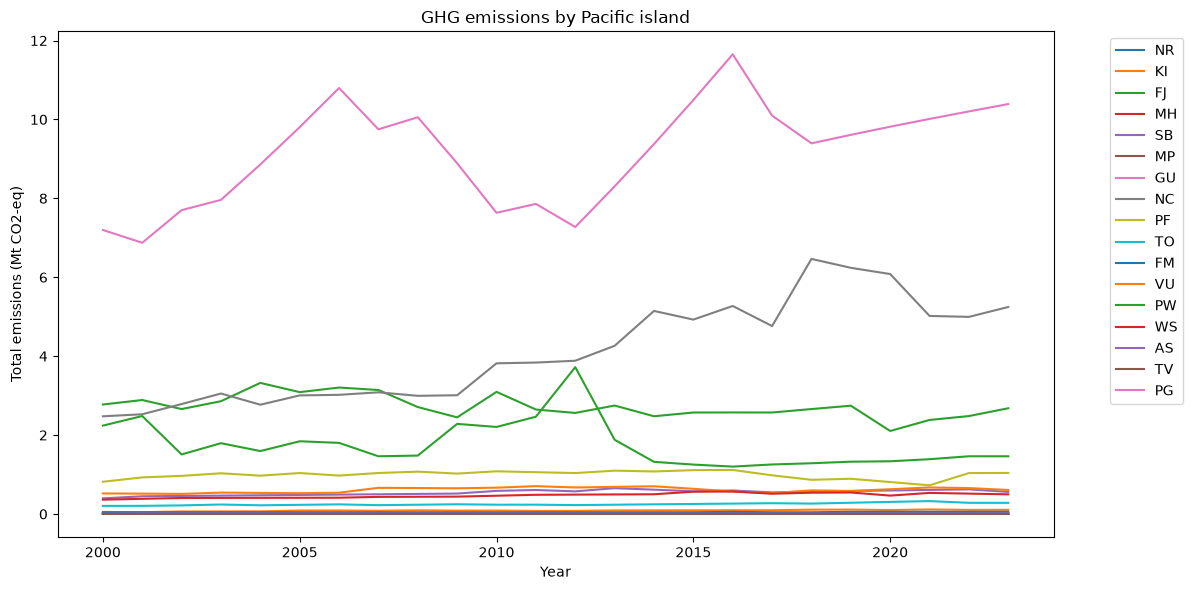

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

for country in merged['GEO_PICT'].unique():
    data = merged[merged['GEO_PICT'] == country]
    ax.plot(data['year'], data['total_emissions_kg'] / 1e9, label=country)

ax.set_xlabel('Year')
ax.set_ylabel('Total emissions (Mt CO2-eq)')
ax.set_title('GHG emissions by Pacific island')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [26]:
lca_wide = merged.pivot(index='iso3_code', columns='year', values='total_emissions_kg').reset_index()

lca_wide.insert(0, 'r_c', lca_wide['iso3_code'])
lca_wide.insert(1, 'impact', 'GWP_100')
lca_wide.insert(2, 'impact_unit', 'kg CO2-eq')
lca_wide = lca_wide.drop(columns='iso3_code')

print(lca_wide.head(3))

year  r_c   impact impact_unit          2000          2001          2002  \
0     ASM  GWP_100   kg CO2-eq  5.685500e+06  1.141060e+07  1.141240e+07   
1     FJI  GWP_100   kg CO2-eq  2.775000e+09  2.888626e+09  2.659952e+09   
2     FSM  GWP_100   kg CO2-eq  4.481760e+07  4.494600e+07  4.497920e+07   

year          2003          2004          2005          2006  ...  \
0     1.139420e+07  1.136360e+07  1.132340e+07  1.127480e+07  ...   
1     2.858744e+09  3.322591e+09  3.088326e+09  3.205314e+09  ...   
2     4.491400e+07  4.477000e+07  4.456480e+07  4.429160e+07  ...   

year          2014          2015          2016          2017          2018  \
0     1.069320e+07  1.057560e+07  1.044900e+07  1.031720e+07  1.018160e+07   
1     2.477480e+09  2.572018e+09  2.573665e+09  2.572525e+09  2.659822e+09   
2     4.335840e+07  4.348640e+07  5.453750e+07  4.379240e+07  4.396360e+07   

year          2019          2020          2021          2022          2023  
0     1.004180e+07  9.952200

In [27]:
lca_wide.to_csv(
    './pacific_dataviz/A_lca/ext_lca/deterministic/spc__gwp100_lcia.csv',
    index=False
)
print("Saved.")

Saved.


### Save pyaesa external LCA template

Saves total emissions in the format expected by pyaesa's `deterministic_asr()`. File naming convention: `<version_name>__<lcia_method>.csv` → `spc__gwp100_lcia.csv`.

## 3. Climate Change Indicators (Acts 4 & 5)

Fetches sea level anomalies, surface temperature, sea surface temperature, disasters, and tourism arrivals for Pacific islands. These power the consequence narrative in Acts 4 and 5.